## Setup

In [1]:
from dotenv import load_dotenv
from utils import chat_interface
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from agentic.workflow import orchestrator, app
from datetime import datetime, UTC
from pathlib import Path
import json
import traceback
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

In [2]:
load_dotenv()

True

In [3]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.0,
    api_key=os.getenv("OPENAI_API_KEY")
)

## Run

In [4]:
# IDEALLY YOUR ONLY IMPORT HERE IS:
# from agentic.workflow import orchestrator

# 15 rubric-friendly test cases:
# - resolved via KB / normal flow
# - escalated billing / blocked account / missing profile / unsafe auto-resolve
# - edge cases / ambiguous input / empty-ish input / repeat issue

test_cases = [
    {
        "name": "01_reservation_help_general",
        "thread_id": "demo-01",
        "user_id": "f556c0",
        "message": "Can you help me understand how reservations work?",
        "expected_issue_type": "reservation_issue",
        "expected_behavior": "auto_handle_or_resolve",
    },
    {
        "name": "02_how_to_cancel_reservation",
        "thread_id": "demo-02",
        "user_id": "f1f10d",
        "message": "How do I cancel my reservation?",
        "expected_issue_type": "reservation_issue",
        "expected_behavior": "auto_handle_or_resolve",
    },
    {
        "name": "03_booking_question",
        "thread_id": "demo-03",
        "user_id": "e6376d",
        "message": "How do I make a booking?",
        "expected_issue_type": "reservation_issue",
        "expected_behavior": "auto_handle_or_resolve",
    },
    {
        "name": "04_double_charge_refund",
        "thread_id": "demo-04",
        "user_id": "b7c921",
        "message": "I was charged twice for the same reservation and want a refund.",
        "expected_issue_type": "billing_issue",
        "expected_behavior": "escalate",
    },
    {
        "name": "05_billing_unknown_charge",
        "thread_id": "demo-05",
        "user_id": "c3d442",
        "message": "There is a charge on my account I do not recognize.",
        "expected_issue_type": "billing_issue",
        "expected_behavior": "escalate",
    },
    {
        "name": "06_account_locked",
        "thread_id": "demo-06",
        "user_id": "a4ab87",
        "message": "My account is locked and I cannot sign in.",
        "expected_issue_type": "blocked_account",
        "expected_behavior": "escalate",
    },
    {
        "name": "07_account_blocked_access",
        "thread_id": "demo-07",
        "user_id": "888fb2",
        "message": "It says my account is blocked. How do I get access back?",
        "expected_issue_type": "blocked_account",
        "expected_behavior": "escalate",
    },
    {
        "name": "08_reschedule_request",
        "thread_id": "demo-08",
        "user_id": "e2f774",
        "message": "How can I reschedule my reservation?",
        "expected_issue_type": "reservation_issue",
        "expected_behavior": "auto_handle_or_resolve",
    },
    {
        "name": "09_no_show_fee_question",
        "thread_id": "demo-09",
        "user_id": "f9a305",
        "message": "Why was I charged a no-show fee?",
        "expected_issue_type": "billing_issue",
        "expected_behavior": "likely_escalate",
    },
    {
        "name": "10_existing_open_billing_issue_same_user",
        "thread_id": "demo-10",
        "user_id": "88382b",
        "message": "I still need help with the billing problem I reported earlier.",
        "expected_issue_type": "billing_issue",
        "expected_behavior": "existing_open_escalation",
    },
    {
        "name": "11_missing_profile_user",
        "thread_id": "demo-11",
        "user_id": "missing-user-001",
        "message": "I need help changing my reservation.",
        "expected_issue_type": "reservation_issue",
        "expected_behavior": "escalate_missing_profile",
    },
    {
        "name": "12_ambiguous_short_message",
        "thread_id": "demo-12",
        "user_id": "a1d556",
        "message": "help",
        "expected_issue_type": "other",
        "expected_behavior": "likely_escalate",
    },
    {
        "name": "13_empty_like_message",
        "thread_id": "demo-13",
        "user_id": "c4f778",
        "message": "...",
        "expected_issue_type": "other",
        "expected_behavior": "likely_escalate",
    },
    {
        "name": "14_how_do_i_change_booking",
        "thread_id": "demo-14",
        "user_id": "d5a889",
        "message": "How do I change my booking date?",
        "expected_issue_type": "reservation_issue",
        "expected_behavior": "auto_handle_or_resolve",
    },
    {
        "name": "15_high_risk_refund_and_locked_account",
        "thread_id": "demo-15",
        "user_id": "d8e113",
        "message": "My account is locked and I also need a refund for an incorrect charge.",
        "expected_issue_type": "billing_issue",
        "expected_behavior": "escalate",
    },
]

LOG_DIR = Path("demo_logs")
LOG_DIR.mkdir(exist_ok=True)

JSONL_PATH = LOG_DIR / "ticket_workflow_logs.jsonl"
SUMMARY_PATH = LOG_DIR / "ticket_workflow_summary.json"


def safe_serialize(obj):
    try:
        json.dumps(obj)
        return obj
    except TypeError:
        return str(obj)


def extract_message_text(messages):
    return [
        {
            "type": getattr(m, "type", m.__class__.__name__),
            "content": getattr(m, "content", str(m)),
        }
        for m in (messages or [])
    ]


def get_state_history_safe(thread_id):
    config = {"configurable": {"thread_id": thread_id}}
    try:
        history = list(app.get_state_history(config=config))
        return [safe_serialize(step) for step in history]
    except Exception as e:
        return [{"history_error": str(e)}]


def normalize_result(result):
    result = result or {}
    routing = result.get("routing") or {}

    return {
        "issue_type": result.get("issue_type"),
        "issue_summary": result.get("issue_summary"),
        "needs_human_review": routing.get("needs_human_review", result.get("needs_human_review")),
        "needs_escalation": routing.get("needs_escalation", result.get("needs_escalation")),
        "create_new_escalation": routing.get(
            "create_new_escalation",
            result.get("create_new_escalation"),
        ),
        "routing_reason": routing.get("reason", result.get("routing_decision")),
        "safe_to_auto_resolve": result.get("safe_to_auto_resolve"),
        "profile": result.get("profile"),
        "reservations": result.get("reservations"),
        "tickets": result.get("tickets"),
        "articles": result.get("articles"),
        "kb_query": result.get("kb_query"),
        "resolver_outcome": result.get("resolver_outcome"),
        "resolution_confidence": result.get("resolution_confidence"),
        "customer_message": result.get("customer_message"),
        "escalation_reason": result.get("escalation_reason", routing.get("reason")),
        "escalation_result": result.get("escalation_result"),
        "final_response": result.get("final_response"),
        "messages": result.get("messages", []),
        "error": result.get("error"),
    }


def build_error_log(case, error):
    return {
        "timestamp": datetime.now(UTC).isoformat(),
        "test_name": case["name"],
        "thread_id": case["thread_id"],
        "user_id": case["user_id"],
        "input_message": case["message"],
        "expected_behavior": case.get("expected_behavior"),
        "expected_issue_type": case.get("expected_issue_type"),
        "status": "error",
        "classification": {},
        "routing": {},
        "retrieval": {},
        "resolution": {},
        "escalation": {},
        "final_action": {},
        "messages": [],
        "error": {
            "type": error.__class__.__name__,
            "message": str(error),
            "traceback": traceback.format_exc(),
        },
    }


def build_success_log(case, result):
    normalized = normalize_result(result)

    return {
        "timestamp": datetime.now(UTC).isoformat(),
        "test_name": case["name"],
        "thread_id": case["thread_id"],
        "user_id": case["user_id"],
        "input_message": case["message"],
        "expected_behavior": case.get("expected_behavior"),
        "expected_issue_type": case.get("expected_issue_type"),
        "status": "success",
        "classification": {
            "issue_type": normalized["issue_type"],
            "issue_summary": normalized["issue_summary"],
        },
        "routing": {
            "needs_human_review": normalized["needs_human_review"],
            "needs_escalation": normalized["needs_escalation"],
            "create_new_escalation": normalized["create_new_escalation"],
            "safe_to_auto_resolve": normalized["safe_to_auto_resolve"],
            "routing_decision": normalized["routing_reason"],
        },
        "retrieval": {
            "profile_found": bool(normalized["profile"]),
            "reservations_found": bool(normalized["reservations"]),
            "tickets_found": bool(normalized["tickets"]),
            "articles_found": bool(normalized["articles"]),
            "kb_query": normalized["kb_query"],
            "profile": safe_serialize(normalized["profile"]),
            "reservations": safe_serialize(normalized["reservations"]),
            "tickets": safe_serialize(normalized["tickets"]),
            "articles": safe_serialize(normalized["articles"]),
        },
        "resolution": {
            "resolver_outcome": normalized["resolver_outcome"],
            "resolution_confidence": normalized["resolution_confidence"],
            "safe_to_auto_resolve": normalized["safe_to_auto_resolve"],
            "customer_message": normalized["customer_message"],
        },
        "escalation": {
            "escalation_reason": normalized["escalation_reason"],
            "escalation_result": safe_serialize(normalized["escalation_result"]),
        },
        "final_action": {
            "final_response": normalized["final_response"],
        },
        "messages": extract_message_text(normalized["messages"]),
        "error": normalized["error"],
    }


def build_audit_log(case, result=None, error=None):
    if error is not None:
        return build_error_log(case, error)
    return build_success_log(case, result)


def print_compact_result(log):
    print("=" * 90, flush=True)
    print(f"TEST: {log['test_name']}", flush=True)
    print(f"THREAD: {log['thread_id']} | USER: {log['user_id']}", flush=True)
    print(f"INPUT: {log['input_message']}", flush=True)
    print(f"STATUS: {log['status']}", flush=True)
    print(f"EXPECTED BEHAVIOR: {log.get('expected_behavior')}", flush=True)
    print(f"EXPECTED ISSUE TYPE: {log.get('expected_issue_type')}", flush=True)

    if log["status"] == "success":
        print(f"ISSUE TYPE: {log['classification'].get('issue_type')}", flush=True)
        print(f"NEEDS ESCALATION: {log['routing'].get('needs_escalation')}", flush=True)
        print(f"CREATE NEW ESCALATION: {log['routing'].get('create_new_escalation')}", flush=True)
        print(f"RESOLUTION CONFIDENCE: {log['resolution'].get('resolution_confidence')}", flush=True)
        print(f"RESOLVER OUTCOME: {log['resolution'].get('resolver_outcome')}", flush=True)
        print(f"ESCALATION REASON: {log['escalation'].get('escalation_reason')}", flush=True)
        print(f"FINAL RESPONSE: {log['final_action'].get('final_response')}", flush=True)
        print("TOOLS / RETRIEVAL:", flush=True)
        print(
            f"  profile={log['retrieval'].get('profile_found')}, "
            f"reservations={log['retrieval'].get('reservations_found')}, "
            f"tickets={log['retrieval'].get('tickets_found')}, "
            f"articles={log['retrieval'].get('articles_found')}",
            flush=True,
        )
    else:
        print(f"ERROR TYPE: {log['error']['type']}", flush=True)
        print(f"ERROR MESSAGE: {log['error']['message']}", flush=True)


def run_test_case(case):
    config = {"configurable": {"thread_id": case["thread_id"]}}

    try:
        result = app.invoke(
            {
                "messages": [HumanMessage(content=case["message"])],
                "user_id": case["user_id"],
            },
            config=config,
        )
        log = build_audit_log(case, result=result)
    except Exception as e:
        log = build_audit_log(case, error=e)

    log["state_history"] = get_state_history_safe(case["thread_id"])
    print_compact_result(log)
    return log


def save_jsonl(records, path):
    with open(path, "w", encoding="utf-8") as f:
        for record in records:
            f.write(json.dumps(record, default=str) + "\n")


def build_summary(records):
    total = len(records)
    success_records = [r for r in records if r["status"] == "success"]
    error_records = [r for r in records if r["status"] == "error"]

    escalated_records = [
        r for r in success_records
        if r.get("routing", {}).get("needs_escalation") is True
    ]

    resolved_records = [
        r for r in success_records
        if r.get("routing", {}).get("needs_escalation") is False
    ]

    return {
        "generated_at": datetime.now(UTC).isoformat(),
        "total_test_cases": total,
        "successful_runs": len(success_records),
        "error_runs": len(error_records),
        "resolved_or_auto_handled": len(resolved_records),
        "escalated_or_flagged": len(escalated_records),
        "log_file": str(JSONL_PATH),
        "tests": [
            {
                "test_name": r["test_name"],
                "thread_id": r["thread_id"],
                "status": r["status"],
                "expected_behavior": r.get("expected_behavior"),
                "expected_issue_type": r.get("expected_issue_type"),
                "issue_type": r.get("classification", {}).get("issue_type"),
                "needs_escalation": r.get("routing", {}).get("needs_escalation"),
                "create_new_escalation": r.get("routing", {}).get("create_new_escalation"),
                "resolver_outcome": r.get("resolution", {}).get("resolver_outcome"),
                "final_response": r.get("final_action", {}).get("final_response"),
                "error": r.get("error"),
            }
            for r in records
        ],
    }


all_logs = []

for case in test_cases:
    log = run_test_case(case)
    all_logs.append(log)

save_jsonl(all_logs, JSONL_PATH)

summary = build_summary(all_logs)
with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=str)

print("\n" + "=" * 90, flush=True)
print("FINAL SUMMARY", flush=True)
print(json.dumps(summary, indent=2, default=str), flush=True)
print(f"\nSaved structured logs to: {JSONL_PATH}", flush=True)
print(f"Saved summary to: {SUMMARY_PATH}", flush=True)

[05/29/26 20:13:28] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=790089;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=115389;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

TEST: 01_reservation_help_general
THREAD: demo-01 | USER: f556c0
INPUT: Can you help me understand how reservations work?
STATUS: success
EXPECTED BEHAVIOR: auto_handle_or_resolve
EXPECTED ISSUE TYPE: reservation_issue
ISSUE TYPE: reservation_issue
NEEDS ESCALATION: False
CREATE NEW ESCALATION: False
RESOLUTION CONFIDENCE: high
RESOLVER OUTCOME: resolved
ESCALATION REASON: auto_handle
FINAL RESPONSE: Reservations work by allowing you to book events through the app. You can confirm your reservation by checking 'My Reservations' in the app or looking for a confirmation email. If you need more details, feel free to ask!
TOOLS / RETRIEVAL:
  profile=False, reservations=False, tickets=False, articles=True


[05/29/26 20:13:31] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=279278;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=728614;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

TEST: 02_how_to_cancel_reservation
THREAD: demo-02 | USER: f1f10d
INPUT: How do I cancel my reservation?
STATUS: success
EXPECTED BEHAVIOR: auto_handle_or_resolve
EXPECTED ISSUE TYPE: reservation_issue
ISSUE TYPE: reservation_issue
NEEDS ESCALATION: False
CREATE NEW ESCALATION: False
RESOLUTION CONFIDENCE: high
RESOLVER OUTCOME: resolved
ESCALATION REASON: auto_handle
FINAL RESPONSE: You can cancel your reservation by opening 'My Reservations' in the app, selecting the event you want to cancel, and tapping 'Cancel Reservation'. Please note that some events may have cancellation deadlines or restrictions.
TOOLS / RETRIEVAL:
  profile=False, reservations=False, tickets=False, articles=True


[05/29/26 20:13:32] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=762133;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=211925;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

...

TEST: 13_empty_like_message
THREAD: demo-13 | USER: c4f778
INPUT: ...
STATUS: success
EXPECTED BEHAVIOR: likely_escalate
EXPECTED ISSUE TYPE: other
ISSUE TYPE: other
NEEDS ESCALATION: True
CREATE NEW ESCALATION: True
RESOLUTION CONFIDENCE: unknown
RESOLVER OUTCOME: unresolved
ESCALATION REASON: other_needs_escalation
FINAL RESPONSE: I wasn’t able to safely resolve this automatically, so I created a support escalation for human review.
TOOLS / RETRIEVAL:
  profile=False, reservations=False, tickets=False, articles=True


[05/29/26 20:13:54] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=382446;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=5646;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

TEST: 14_how_do_i_change_booking
THREAD: demo-14 | USER: d5a889
INPUT: How do I change my booking date?
STATUS: success
EXPECTED BEHAVIOR: auto_handle_or_resolve
EXPECTED ISSUE TYPE: reservation_issue
ISSUE TYPE: reservation_issue
NEEDS ESCALATION: False
CREATE NEW ESCALATION: False
RESOLUTION CONFIDENCE: high
RESOLVER OUTCOME: resolved
ESCALATION REASON: auto_handle
FINAL RESPONSE: You can change your booking date by opening the CultPass app, going to 'My Reservations', selecting the event, and following the prompts to change the date.
TOOLS / RETRIEVAL:
  profile=False, reservations=False, tickets=False, articles=True


[05/29/26 20:13:56] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=756406;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=264561;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

TEST: 15_high_risk_refund_and_locked_account
THREAD: demo-15 | USER: d8e113
INPUT: My account is locked and I also need a refund for an incorrect charge.
STATUS: success
EXPECTED BEHAVIOR: escalate
EXPECTED ISSUE TYPE: billing_issue
ISSUE TYPE: billing_issue
NEEDS ESCALATION: True
CREATE NEW ESCALATION: False
RESOLUTION CONFIDENCE: high
RESOLVER OUTCOME: needs_escalation
ESCALATION REASON: existing_open_escalation
FINAL RESPONSE: This issue already has an open escalation, so it will continue with human support.
TOOLS / RETRIEVAL:
  profile=True, reservations=True, tickets=True, articles=True

FINAL SUMMARY
{
  "generated_at": "2026-05-29T20:13:56.273764+00:00",
  "total_test_cases": 15,
  "successful_runs": 15,
  "error_runs": 0,
  "resolved_or_auto_handled": 5,
  "escalated_or_flagged": 10,
  "log_file": "demo_logs/ticket_workflow_logs.jsonl",
  "tests": [
    {
      "test_name": "01_reservation_help_general",
      "thread_id": "demo-01",
      "status": "success",
      "expected_b

In [5]:
def run_one_turn(graph_app, thread_id, user_id, text):
    config = {"configurable": {"thread_id": thread_id}}
    return graph_app.invoke(
        {
            "messages": [HumanMessage(content=text)],
            "user_id": user_id,
        },
        config=config,
    )

In [6]:
for case in test_cases:
    result = run_one_turn(
        app,
        case["thread_id"],
        case["user_id"],
        case["message"],
    )
    print(case["thread_id"], "done")

[05/29/26 20:14:15] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=90594;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=473343;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

demo-01 done


[05/29/26 20:14:17] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=149814;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=462986;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

demo-02 done


[05/29/26 20:14:18] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=553606;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=591414;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

...

demo-13 done


[05/29/26 20:14:36] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=851054;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=825606;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

demo-14 done


[05/29/26 20:14:38] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=891331;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=236809;file:///opt/venv/lib/python3.13/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

demo-15 done


In [7]:
def extract_message_text(msg):
    content = getattr(msg, "content", "")
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts = []
        for item in content:
            if isinstance(item, dict):
                parts.append(str(item.get("text", item)))
            else:
                parts.append(str(item))
        return " ".join(parts)
    return str(content)

rows = []
thread_ids = [f"demo-{i:02d}" for i in range(1, 16)]

for thread_id in thread_ids:
    config = {"configurable": {"thread_id": thread_id}}
    
    try:
        history = list(orchestrator.get_state_history(config=config))
        
        if not history:
            rows.append({
                "thread_id": thread_id,
                "num_states": 0,
                "has_messages": False,
                "last_message_type": None,
                "last_message_text": "No state history found",
                "issue_type": None,
                "needs_escalation": None,
                "create_new_escalation": None,
                "resolver_outcome": None,
                "final_response": None,
            })
            continue
        
        latest_state = history[0]
        values = getattr(latest_state, "values", {}) or {}
        messages = values.get("messages", [])
        last_msg = messages[-1] if messages else None
        
        rows.append({
            "thread_id": thread_id,
            "num_states": len(history),
            "has_messages": len(messages) > 0,
            "last_message_type": type(last_msg).__name__ if last_msg else None,
            "last_message_text": extract_message_text(last_msg) if last_msg else None,
            "issue_type": values.get("issue_type"),
            "needs_escalation": values.get("needs_escalation"),
            "create_new_escalation": values.get("create_new_escalation"),
            "resolver_outcome": values.get("resolver_outcome"),
            "final_response": values.get("final_response"),
        })
        
    except Exception as e:
        rows.append({
            "thread_id": thread_id,
            "num_states": None,
            "has_messages": None,
            "last_message_type": None,
            "last_message_text": f"ERROR: {e}",
            "issue_type": None,
            "needs_escalation": None,
            "create_new_escalation": None,
            "resolver_outcome": None,
            "final_response": None,
        })

for row in rows:
    print("=" * 100)
    for key, value in row.items():
        print(f"{key}: {value}")

thread_id: demo-01
num_states: None
has_messages: None
last_message_type: None
last_message_text: ERROR: 'function' object has no attribute 'get_state_history'
issue_type: None
needs_escalation: None
create_new_escalation: None
resolver_outcome: None
final_response: None
thread_id: demo-02
num_states: None
has_messages: None
last_message_type: None
last_message_text: ERROR: 'function' object has no attribute 'get_state_history'
issue_type: None
needs_escalation: None
create_new_escalation: None
resolver_outcome: None
final_response: None
thread_id: demo-03
num_states: None
has_messages: None
last_message_type: None
last_message_text: ERROR: 'function' object has no attribute 'get_state_history'
issue_type: None
needs_escalation: None
create_new_escalation: None
resolver_outcome: None
final_response: None
thread_id: demo-04
num_states: None
has_messages: None
last_message_type: None
last_message_text: ERROR: 'function' object has no attribute 'get_state_history'
issue_type: None
needs_e

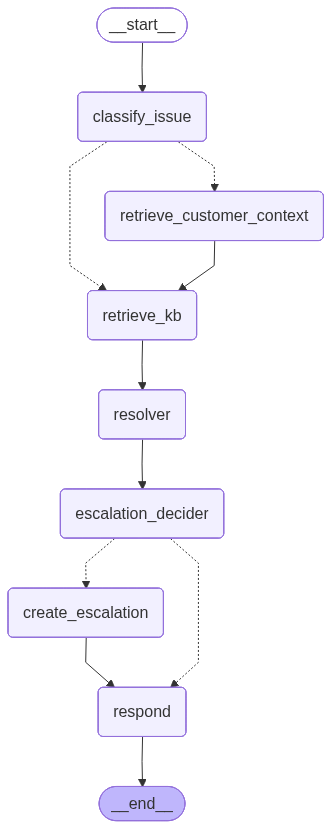

In [8]:
graph = orchestrator()
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)